# Differential peaks generate bed

In [1]:
here::i_am("rna_atac/differential/v2/01_early_defects.ipynb")

source(here::here("settings.R"))
source(here::here("utils.R"))

here() starts at /rds/project/rds-SDzz0CATGms/users/bt392/09_Eomes_invitro_blood/code

Warning message:
“package ‘rtracklayer’ was built under R version 4.2.3”


In [2]:
args = list()
args$accessibility = file.path(io$basedir, 'results/rna_atac/differential/v2/Accessibility/')

In [3]:
outdir = paste0(io$basedir, '/results/atac/chrombpnet/')
dir.create(outdir, recursive = T)

Warning message in dir.create(outdir, recursive = T):
“'/rds/project/rds-SDzz0CATGms/users/bt392/09_Eomes_invitro_blood/results/atac/chrombpnet' already exists”


In [4]:
args$celltypes = c('Primitive_Streak', 'Early_Mes_EOd', 'Early_Mes_EOi')

In [5]:
# Load differential ATAC
DARs = fread(sprintf('%s/DARs_edgeR_pb.txt.gz', args$accessibility))[celltype %in% args$celltypes] %>% 
        .[,sig:=ifelse(abs(logFC)>0.5 & padj_fdr < 0.05, TRUE, FALSE)] %>% 
        .[sig == T] %>% .[, sig := NULL]

Warning message:
“Using `bins = 30` by default. Pick better value with the argument `bins`.”


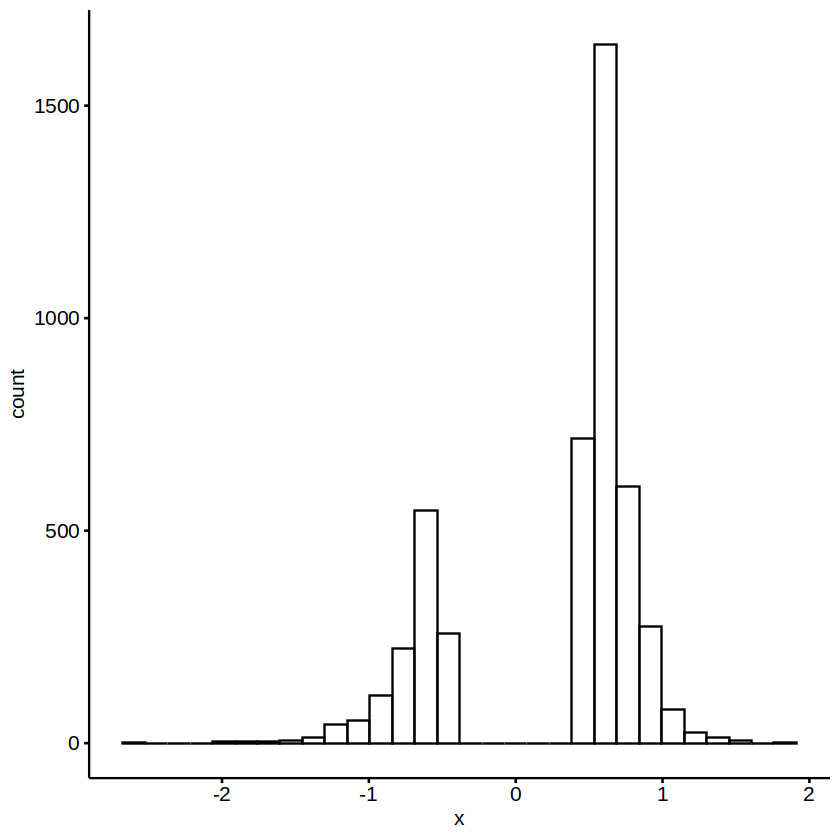

In [16]:
gghistogram(DARs$logFC)

In [18]:
peaks = DARs %>%
    .[order(-abs(logFC))] %>%
    unique(by = 'peak') %>%
    .[,`:=`(
            start = str_split(peak, ':') %>% 
                map_chr(2) %>% 
                str_split(., '-') %>%
                map_chr(1) %>% 
                as.numeric(.),
            end = str_split(peak, ':') %>% 
                map_chr(2) %>% 
                str_split(., '-') %>%
                map_chr(2) %>% 
                as.numeric(.)
            )
      ] %>%
    .[, middle := start + (end - start) / 2] %>%
    .[,`:=`(
            seqnames = str_split(peak, ':') %>% 
                map_chr(1),
            start = middle - 1057, 
            end = middle + 1057,
            column4 = celltype,
            column5 = padj_fdr,
            column6 = logFC,
            column7 = '.',
            column8 = '.',
            column9 = '.',
            column10 = 1057)] %>% 
    .[,.(seqnames, 
         start, 
         end, 
         column4,
         column5,
         column6,
         column7,
         column8,
         column9,
         column10)]

nrow(peaks)
head(peaks)

[1] 4428

seqnames,start,end,column4,column5,column6,column7,column8,column9,column10
<chr>,<dbl>,<dbl>,<chr>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<dbl>
chr7,122509033,122511147,Early_Mes_EOd,5.81e-45,-2.561,.,.,.,1057
chr6,48490932,48493046,Early_Mes_EOd,2.29e-28,-2.058,.,.,.,1057
chr2,178839982,178842096,Early_Mes_EOd,1.60e-41,-2.050,.,.,.,1057
chr7,40814699,40816813,Early_Mes_EOd,5.89e-33,-2.019,.,.,.,1057
chr1,72805182,72807296,Early_Mes_EOd,9.19e-46,-1.953,.,.,.,1057
chr12,107264325,107266439,Early_Mes_EOd,1.65e-30,-1.917,.,.,.,1057


In [20]:
ArchRProject = ArchR::loadArchRProject(io$archR.directory)

Successfully loaded ArchRProject!


                                                   / |
                                                 /    \
            .                                  /      |.
            \\\                              /        |.
              \\\                          /           `|.
                \\\                      /              |.
                  \                    /                |\
                  \\#####\           /                  ||
                ==###########>      /                   ||
                 \\##==......\    /                     ||
            ______ =       =|__ /__                     ||      \\\
        ,--' ,----`-,__ ___/'  --,-`-===================##========>
       \               '        ##_______ _____ ,--,__,=##,__   ///
        ,    __==    ___,-,__,--'#'  ==='      `-'    | ##,-/
        -,____,---'       \\####\\________________,--\\_##,/
           ___      .______        ______  __    __  .____

In [21]:
peaks.gr = GenomicRanges::makeGRangesFromDataFrame(peaks, keep.extra.columns = T)
overlaps = GenomicRanges::findOverlaps(peaks.gr, ArchRProject@genomeAnnotation$blacklist)

peaks.gr = peaks.gr[-queryHits(overlaps)]

In [22]:
peaks.gr

GRanges object with 4420 ranges and 7 metadata columns:
         seqnames              ranges strand |       column4   column5
            <Rle>           <IRanges>  <Rle> |   <character> <numeric>
     [1]     chr7 122509033-122511147      * | Early_Mes_EOd  5.81e-45
     [2]     chr6   48490932-48493046      * | Early_Mes_EOd  2.29e-28
     [3]     chr2 178839982-178842096      * | Early_Mes_EOd  1.60e-41
     [4]     chr7   40814699-40816813      * | Early_Mes_EOd  5.89e-33
     [5]     chr1   72805182-72807296      * | Early_Mes_EOd  9.19e-46
     ...      ...                 ...    ... .           ...       ...
  [4416]    chr14   65148279-65150393      * | Early_Mes_EOd  0.000286
  [4417]     chr6   39779595-39781709      * | Early_Mes_EOd  0.000496
  [4418]    chr11 118544772-118546886      * | Early_Mes_EOd  0.000557
  [4419]     chr9   21163213-21165327      * | Early_Mes_EOd  0.000813
  [4420]     chr2   70619392-70621506      * | Early_Mes_EOd  0.001030
           column6   

In [24]:
peaks = as.data.table(peaks.gr)[,`:=`(width=NULL, strand=NULL)]
fwrite(peaks, sprintf('%s/early_differential_peaks.bed', outdir), col.names = F, sep = '\t')

In [26]:
writeLines(paste0(
    sapply(args$celltypes, function(celltype){
        print(sprintf('sbatch marker_predictions_args.sh %s', 
                       celltype))
    })),
   "get_contributions.txt")

[1] "sbatch marker_predictions_args.sh Primitive_Streak"
[1] "sbatch marker_predictions_args.sh Early_Mes_EOd"
[1] "sbatch marker_predictions_args.sh Early_Mes_EOi"


## Assess

In [38]:
library(ggseqlogo)
library(rhdf5)

args$celltypes = c('Primitive_Streak', 'Early_Mes_EOi')

In [37]:
args$celltypes

[1] "Primitive_Streak" "Early_Mes_EOd"    "Early_Mes_EOi"

In [27]:
peaks = fread('../../../results/atac/chrombpnet/predictions/Primitive_Streak_prediction.interpreted_regions.bed') %>% 
    .[, I := .I]

In [54]:
row = peaks %>% .[V4 == 'Primitive_Streak'] %>% .$I %>% .[1]
width = 350
plot_peak = function(row, width = 350, celltypes_plot = args$celltypes, centre_on_max = FALSE){
    profiles_peak = lapply(profiles, function(x){
        tmp = x[(2114 * (row-1)*4 + 1): (2114 * ((row-1) * 4) + 2114*4)]
        genome_endo = data.table(A = tmp[1:2114],
                   C = tmp[2115:4228],
                   G =  tmp[4229:6342],
                   T =  tmp[6343:8456]
                   ) %>% 
                    .[, position := .I] 

        if(centre_on_max){ # Centering does not work yet
            centre = which(profiles_peak[[celltypes_plot]] == max(profiles_peak[[celltypes_plot]]))/4+1
            genome_endo = genome_endo %>% 
                    .[position > centre - width/2 & position < centre + width/2] %>% 
                    .[, position := NULL]
        }else{
            genome_endo = genome_endo %>% 
                .[position > 1057 - width/2 & position < 1057 + width/2] %>% 
                .[, position := NULL]
        }
        
        genome_endo = as.matrix(t(genome_endo))
    })

    profiles_peak_tmp = profiles_peak[celltypes_plot]
    plots = lapply(1:length(profiles_peak_tmp), function(x){
          p1 = ggseqlogo(profiles_peak_tmp[[x]], method='custom', seq_type='dna') + ylab('my custom height') + 
            geom_hline(yintercept = 0) +
            ylim(min(sapply(profiles_peak_tmp, min)), max(sapply(profiles_peak_tmp, max))) + 
            ggtitle(names(profiles_peak_tmp)[[x]]) + 
                theme_bw() + 
                theme(panel.grid = element_blank(), 
                      panel.background = element_rect(color = 'black', fill = NA, linewidth = 1),
                      axis.text.y = element_text(size = 15),
                     axis.title.y = element_blank(),
                     axis.text.x = element_blank(),
                     axis.ticks.x = element_blank())
    })

    ggarrange(plotlist = plots, ncol = 1, align = 'hv')
}

In [64]:
profiles = mclapply(args$celltypes, function(celltype){
    tmp = h5read(
        sprintf('../../../results/atac/chrombpnet/predictions/%s_prediction.profile_scores.h5', celltype), 
        "/projected_shap/seq")
    return(tmp)
},mc.cores = 8)

names(profiles) = args$celltypes

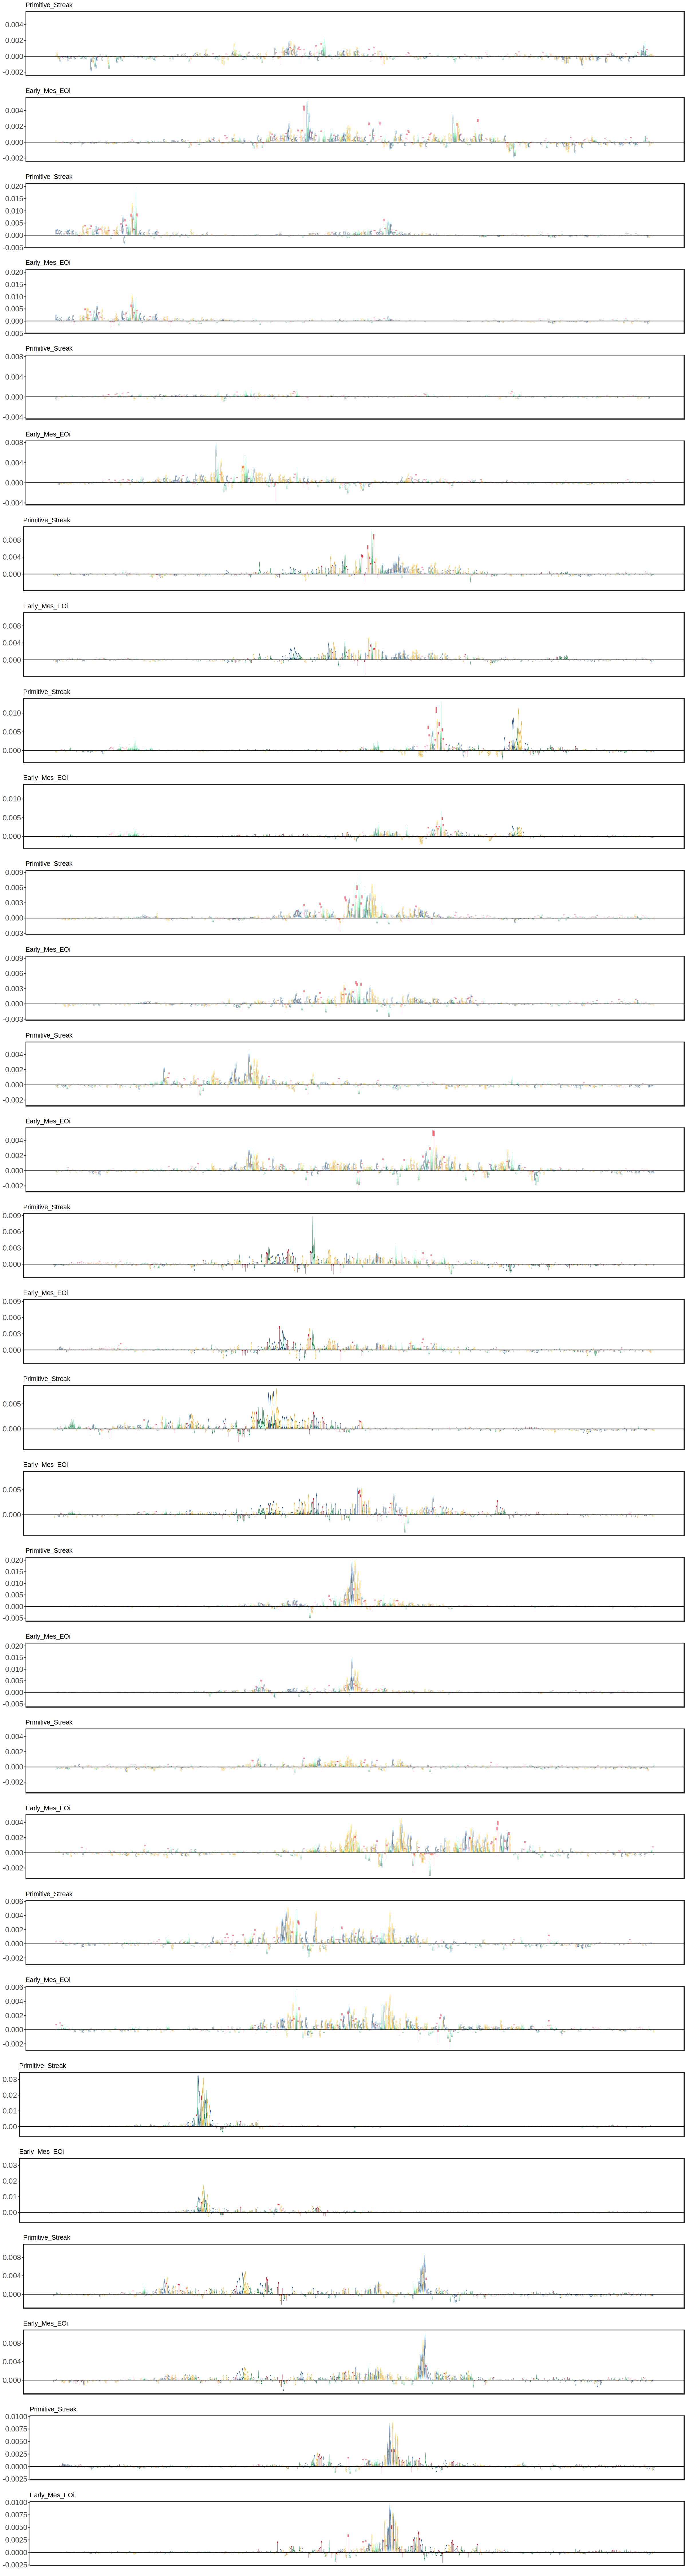

In [65]:
options(repr.plot.width = 20, repr.plot.height = 5*15)

ggarrange(plotlist = mclapply(1:15, function(x){
    plot_peak(row = peaks %>% .[order(V6)] %>% .[V4 == 'Primitive_Streak'] %>% .$I %>% .[x], width = 600)
}, mc.cores = 15), align = 'hv', ncol = 1)

In [60]:
profiles = mclapply(args$celltypes, function(celltype){
    tmp = h5read(
        sprintf('../../../results/atac/chrombpnet/predictions/%s_prediction.counts_scores.h5', celltype), 
        "/projected_shap/seq")
    return(tmp)
},mc.cores = 8)

names(profiles) = args$celltypes

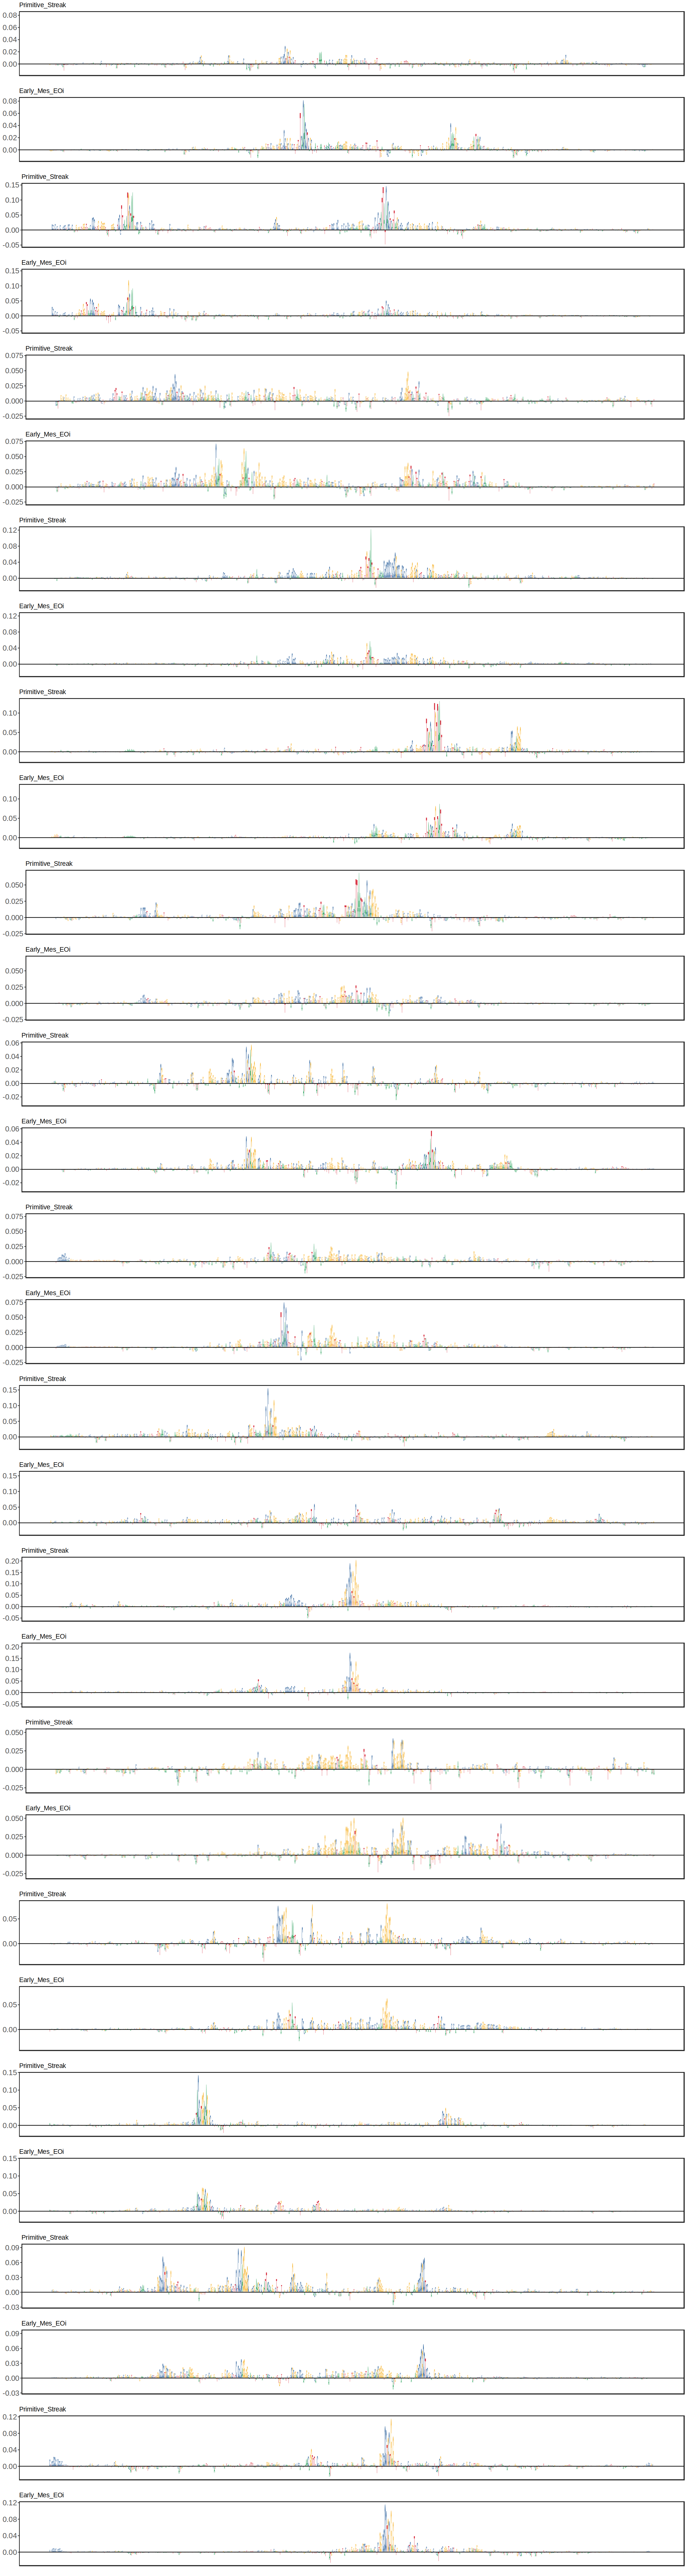

In [63]:
options(repr.plot.width = 20, repr.plot.height = 5*15)

ggarrange(plotlist = mclapply(1:15, function(x){
    plot_peak(row = peaks %>% .[order(V6)] %>% .[V4 == 'Primitive_Streak'] %>% .$I %>% .[x], width = 600)
}, mc.cores = 24), align = 'hv', ncol = 1)